# Data Cleaning

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data set 

In [2]:
df=pd.read_csv("data_set.csv")
df

,customer_id,age,gender,city,income,education,experience_years,monthly_spending,credit_score,signup_date,has_credit_card,loan_amount,employment_type,defaulted
0,C100000,18.0,Male,Faisalabad,97203.41,Bachelor,33,34323.67,728.0,2020-01-01,Yes,162409.81,Unemployed,0
1,C100001,56.0,Female,Islamabad,132084.64,Matric,20,36955.51,439.0,2020-01-02,Yes,207532.68,Government,0
2,C100002,51.0,Female,Lahore,39789.24,Bachelor,26,30520.91,516.0,2020-01-03,Yes,261934.54,Government,0
3,C100003,21.0,Female,Islamabad,110957.74,Matric,23,34385.96,520.0,2020-01-04,No,NaN,Student,1
4,C100004,69.0,Female,Rawalpindi,127385.88,Master,18,34126.80,715.0,2020-01-05,No,92532.55,Business,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3030,C102051,58.0,Male,Rawalpindi,36529.58,Bachelor,15,41294.78,803.0,2025-08-13,Yes,373470.82,Unemployed,0
3031,C100203,42.0,Male,Lahore,65506.98,Intermediate,34,24988.27,427.0,2020-07-22,Yes,276642.15,Private,0
3032,C102772,48.0,Male,Karachi,155931.04,PhD,8,38071.27,NaN,2027-08-04,No,272737.10,Business,0
3033,C100852,23.0,Female,Karachi,95938.08,Intermediate,32,49512.70,663.0,2022-05-02,Yes,251914.61,Unemployed,0


## Handel the missing values and duplicates

In [4]:
df.isnull().sum()

customer_id           0
age                  90
gender                0
city                 76
income              150
education            60
experience_years      0
monthly_spending    120
credit_score         61
signup_date           0
has_credit_card       0
loan_amount         121
employment_type       0
defaulted             0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       3035 non-null   str    
 1   age               2945 non-null   float64
 2   gender            3035 non-null   str    
 3   city              2959 non-null   str    
 4   income            2885 non-null   str    
 5   education         2975 non-null   str    
 6   experience_years  3035 non-null   int64  
 7   monthly_spending  2915 non-null   float64
 8   credit_score      2974 non-null   str    
 9   signup_date       3035 non-null   str    
 10  has_credit_card   3035 non-null   str    
 11  loan_amount       2914 non-null   float64
 12  employment_type   3035 non-null   str    
 13  defaulted         3035 non-null   int64  
dtypes: float64(3), int64(2), str(9)
memory usage: 332.1 KB


###  Handel the Duplicates 

In [6]:
for col in df.select_dtypes(include="object"):
    print(col)
    print(df[col].value_counts(dropna=False).head(10))

customer_id
customer_id
C100203    2
C100568    2
C100584    2
C100674    2
C100718    2
C100852    2
C100891    2
C100992    2
C101111    2
C101123    2
Name: count, dtype: int64
gender
gender
Male        1540
Female      1455
F             14
 FEMALE       12
M              8
male           6
Name: count, dtype: int64
city
city
Islamabad     610
Karachi       590
Faisalabad    586
Lahore        583
Rawalpindi    570
NaN            76
KARACHI         9
Islamabad       6
lahore          5
Name: count, dtype: int64
income
income
NaN          150
missing       16
65506.98       2
67117.72       2
91480.77       2
65042.9        2
60908.43       2
95938.08       2
58855.55       2
106482.66      2
Name: count, dtype: int64
education
education
Bachelor        611
Master          606
PhD             594
Matric          592
Intermediate    572
NaN              60
Name: count, dtype: int64
credit_score
credit_score
NaN        61
353.0      15
unknown    15
566.0      14
537.0      14
596.0   

C:\Users\Cyber\AppData\Local\Temp\ipykernel_9788\626018582.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [7]:
duplicates = df[df.duplicated(subset="customer_id", keep=False)]
duplicates.sort_values("customer_id")

,customer_id,age,gender,city,income,education,experience_years,monthly_spending,credit_score,signup_date,has_credit_card,loan_amount,employment_type,defaulted
203,C100203,42.0,Male,Lahore,65506.98,Intermediate,34,24988.27,427.0,2020-07-22,Yes,276642.15,Private,0
3031,C100203,42.0,Male,Lahore,65506.98,Intermediate,34,24988.27,427.0,2020-07-22,Yes,276642.15,Private,0
568,C100568,42.0,Male,Faisalabad,67117.72,Bachelor,23,36671.61,770.0,2021-07-22,No,298123.97,Government,0
3002,C100568,42.0,Male,Faisalabad,67117.72,Bachelor,23,36671.61,770.0,2021-07-22,No,298123.97,Government,0
3020,C100584,48.0,Male,Faisalabad,91480.77,Intermediate,12,39156.70,454.0,2021-08-07,Yes,308331.38,Government,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3027,C102783,38.0,Female,Islamabad,NaN,Master,2,35409.32,624.0,2027-08-15,No,271575.97,Student,0
3015,C102803,25.0,Male,Faisalabad,97575.41,Matric,5,23509.69,332.0,invalid_date,Yes,211427.02,Student,0
2803,C102803,25.0,Male,Faisalabad,97575.41,Matric,5,23509.69,332.0,invalid_date,Yes,211427.02,Student,0
3019,C102834,67.0,Male,Rawalpindi,73425.25,PhD,18,29137.80,550.0,2027-10-05,No,NaN,Private,0


In [8]:
df = df.drop_duplicates()

In [9]:
df["gender"].duplicated().sum()

np.int64(2994)

In [10]:
df.value_counts("gender")

gender
Male        1520
Female      1440
F             14
 FEMALE       12
M              8
male           6
Name: count, dtype: int64

In [11]:
df["gender"] = df["gender"].str.strip().str.lower()

df["gender"] = df["gender"].replace({
    "m": "Male",
    "male": "Male",
    "f": "Female",
    "female": "Female"
})
df.value_counts("gender")

gender
Male      1534
Female    1466
Name: count, dtype: int64

In [12]:
df.value_counts("city")

city
Islamabad     606
Karachi       586
Faisalabad    579
Lahore        574
Rawalpindi    560
KARACHI         9
Islamabad       6
lahore          5
Name: count, dtype: int64

In [13]:
df["city"] = df["city"].str.strip().str.lower()

df["city"] = df["city"].replace({
    "KARACHI": "Karachi",
    "Islamabad": "Islamabad",
    "lahore": "Lahore"
})
df.value_counts("city")

city
islamabad     612
karachi       595
faisalabad    579
Lahore        579
rawalpindi    560
Name: count, dtype: int64

In [14]:
df.value_counts("education")

education
Bachelor        605
Master          597
Matric          586
PhD             586
Intermediate    566
Name: count, dtype: int64

In [15]:
df.value_counts("employment_type")

employment_type
Private       633
Government    632
Business      601
Student       571
Unemployed    563
Name: count, dtype: int64

### Check Empty and Special Values

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       3000 non-null   str    
 1   age               2910 non-null   float64
 2   gender            3000 non-null   str    
 3   city              2925 non-null   str    
 4   income            2851 non-null   str    
 5   education         2940 non-null   str    
 6   experience_years  3000 non-null   int64  
 7   monthly_spending  2881 non-null   float64
 8   credit_score      2940 non-null   str    
 9   signup_date       3000 non-null   str    
 10  has_credit_card   3000 non-null   str    
 11  loan_amount       2880 non-null   float64
 12  employment_type   3000 non-null   str    
 13  defaulted         3000 non-null   int64  
dtypes: float64(3), int64(2), str(9)
memory usage: 328.3 KB


### Convert the data type of the columns

In [17]:
df["income"] = pd.to_numeric(df["income"], errors="coerce")
df["credit_score"] = pd.to_numeric(df["credit_score"], errors="coerce")

# Handel the Date column

In [18]:
df["signup_date"] = pd.to_datetime(
    df["signup_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [19]:
print(df["signup_date"].dtype)
print("Invalid dates:", df["signup_date"].isna().sum())

datetime64[us]
Invalid dates: 10


In [20]:
df["signup_date"].value_counts(dropna=False)

signup_date
NaT           10
2023-12-04     8
2024-02-15     7
2025-06-15     5
2024-10-03     4
              ..
2028-03-14     1
2028-03-15     1
2028-03-16     1
2028-03-17     1
2028-03-18     1
Name: count, Length: 2971, dtype: int64

In [21]:
df[df["signup_date"].isna()]

,customer_id,age,gender,city,income,education,experience_years,monthly_spending,credit_score,signup_date,has_credit_card,loan_amount,employment_type,defaulted
428,C100428,57.0,Male,karachi,122826.75,Intermediate,30,44527.79,770.0,NaT,Yes,218026.80,Private,0
676,C100676,28.0,Male,karachi,82069.54,Bachelor,34,49459.23,395.0,NaT,Yes,159665.77,Student,0
877,C100877,59.0,Female,rawalpindi,106723.34,Intermediate,9,6457.27,479.0,NaT,Yes,293597.44,Private,1
1290,C101290,45.0,Male,karachi,154782.47,Master,13,12349.18,662.0,NaT,Yes,266495.01,Private,0
1306,C101306,26.0,Male,rawalpindi,82583.71,Matric,20,44629.98,571.0,NaT,No,451979.90,Private,0
1608,C101608,58.0,Male,Lahore,116833.59,PhD,29,32247.38,824.0,NaT,Yes,217932.71,Student,0
2567,C102567,74.0,Male,Lahore,150875.36,PhD,30,42393.13,808.0,NaT,No,158826.79,Private,0
2646,C102646,64.0,Male,Lahore,100182.63,Master,1,47310.38,366.0,NaT,Yes,312516.45,Unemployed,1
2716,C102716,45.0,Female,rawalpindi,102947.22,PhD,2,15517.62,784.0,NaT,No,408328.40,Unemployed,0
2803,C102803,25.0,Male,faisalabad,97575.41,Matric,5,23509.69,332.0,NaT,Yes,211427.02,Student,0


In [22]:
df[df["signup_date"] > "2026-12-31"]

,customer_id,age,gender,city,income,education,experience_years,monthly_spending,credit_score,signup_date,has_credit_card,loan_amount,employment_type,defaulted
2557,C102557,68.0,Female,faisalabad,91927.51,Bachelor,27,31050.71,558.0,2027-01-01,Yes,151874.58,Business,0
2558,C102558,61.0,Male,faisalabad,54002.96,Intermediate,24,24587.14,604.0,2027-02-01,No,235358.04,Business,0
2559,C102559,43.0,Female,Lahore,71342.14,PhD,1,48091.86,NaN,2027-03-01,Yes,85600.92,Unemployed,1
2560,C102560,41.0,Female,faisalabad,52595.83,Master,13,-1977.97,815.0,2027-04-01,Yes,41710.46,Business,0
2561,C102561,24.0,Male,Lahore,73130.12,Matric,22,21150.39,804.0,2027-05-01,Yes,236168.25,Unemployed,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,C102995,52.0,Male,Lahore,61720.95,PhD,22,33887.96,744.0,2028-03-14,Yes,302254.75,Government,0
2996,C102996,57.0,Male,rawalpindi,39240.38,PhD,14,50459.38,448.0,2028-03-15,Yes,312313.61,Unemployed,0
2997,C102997,60.0,Male,rawalpindi,114709.11,Master,13,79268.23,334.0,2028-03-16,Yes,325664.77,Private,0
2998,C102998,51.0,Male,Lahore,131678.22,Intermediate,31,41027.35,550.0,2028-03-17,No,322692.25,Government,1


In [23]:
df["signup_date"].dt.year.value_counts().sort_index()

signup_date
2020.0    362
2021.0    363
2022.0    361
2023.0    369
2024.0    373
2025.0    366
2026.0    361
2027.0    359
2028.0     76
Name: count, dtype: int64

In [24]:
df = df.dropna(subset=["signup_date"]).copy()
df["signup_date"].isnull().sum()

np.int64(0)

In [25]:
for col in df.select_dtypes(include=["object", "string"]):
    blanks = df[col].astype("string").str.strip().eq("").sum()
    print(col, ":", blanks)
df.isnull().sum()

customer_id : 0
gender : 0
city : 0
education : 0
has_credit_card : 0
employment_type : 0


customer_id           0
age                  90
gender                0
city                 75
income              164
education            60
experience_years      0
monthly_spending    119
credit_score         75
signup_date           0
has_credit_card       0
loan_amount         120
employment_type       0
defaulted             0
dtype: int64

## Check the is data normal or skewed

In [26]:
num_col= df.select_dtypes(include="number")
num_col

,age,income,experience_years,monthly_spending,credit_score,loan_amount,defaulted
0,18.0,97203.41,33,34323.67,728.0,162409.81,0
1,56.0,132084.64,20,36955.51,439.0,207532.68,0
2,51.0,39789.24,26,30520.91,516.0,261934.54,0
3,21.0,110957.74,23,34385.96,520.0,NaN,1
4,69.0,127385.88,18,34126.80,715.0,92532.55,0
...,...,...,...,...,...,...,...
2995,52.0,61720.95,22,33887.96,744.0,302254.75,0
2996,57.0,39240.38,14,50459.38,448.0,312313.61,0
2997,60.0,114709.11,13,79268.23,334.0,325664.77,0
2998,51.0,131678.22,31,41027.35,550.0,322692.25,1


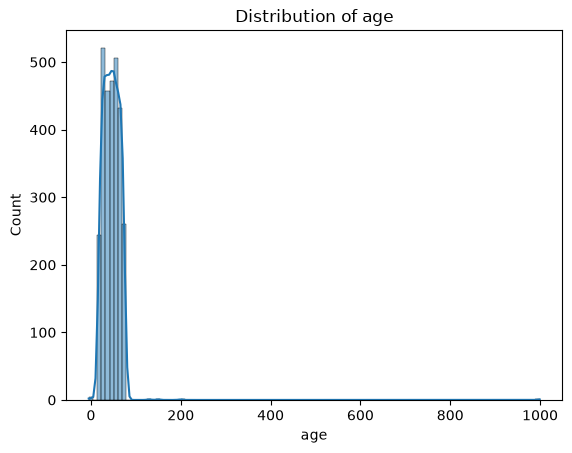

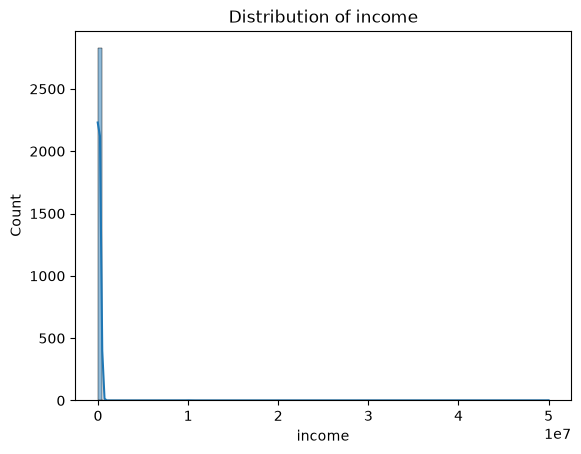

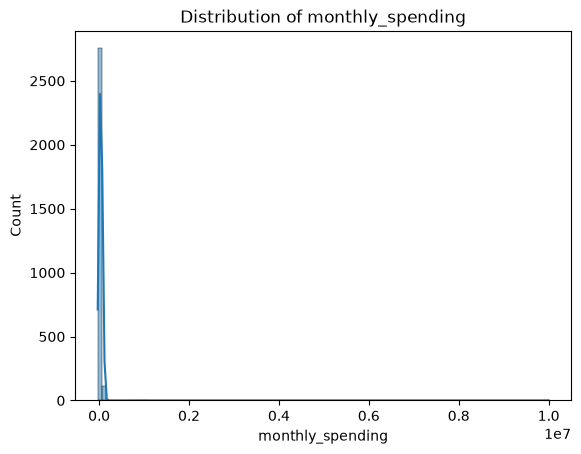

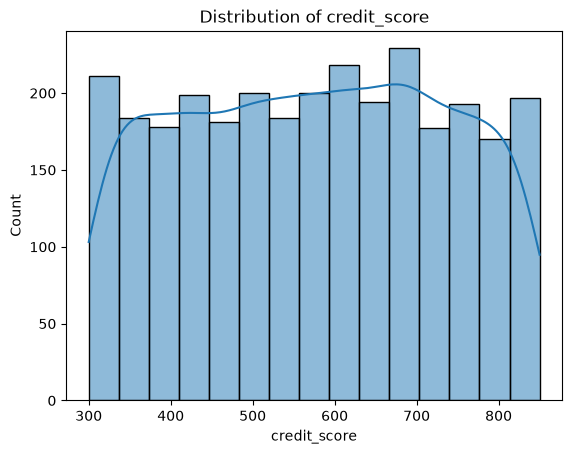

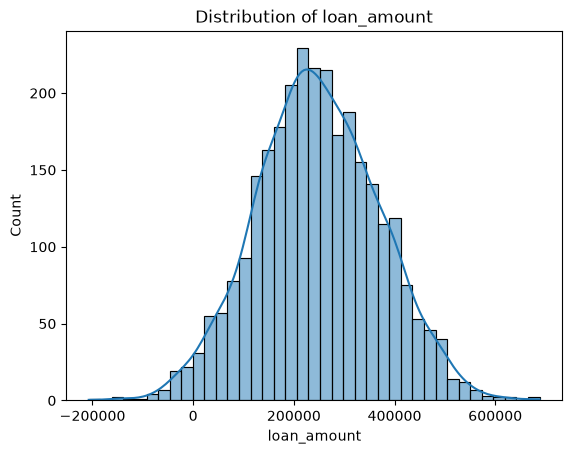

In [27]:
for col in num_col:
    if df[col].isnull().sum() > 0:
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

In [28]:
for col in num_col:
    if df[col].isnull().sum() > 0:
        print(f"\n{col}")
        print("Mean:", df[col].mean())
        print("Median:", df[col].median())


age
Mean: 46.22862068965517
Median: 46.0

income
Mean: 106408.38407643314
Median: 85476.32999999999

monthly_spending
Mean: 39186.442183908046
Median: 34798.72

credit_score
Mean: 574.3770154373927
Median: 577.0

loan_amount
Mean: 247704.90777003483
Median: 243796.305


In [29]:
df["age"] = df["age"].fillna(df["age"].mean())

In [30]:
df["monthly_spending"] = df["monthly_spending"].fillna(
    df["monthly_spending"].median()
)

In [31]:
df["loan_amount"] = df["loan_amount"].fillna(
    df["loan_amount"].mean()
)

In [32]:
df["income"] = df["income"].fillna(df["income"].median())

In [33]:
df["credit_score"] = df["credit_score"].fillna(df["credit_score"].mean())

In [34]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns

for col in cat_cols:
    print(col, ":", df[col].isnull().sum())

customer_id : 0
gender : 0
city : 75
education : 60
has_credit_card : 0
employment_type : 0


In [35]:
df["city"].value_counts(dropna=False)

city
islamabad     612
karachi       592
faisalabad    578
Lahore        576
rawalpindi    557
NaN            75
Name: count, dtype: int64

In [36]:
df["city"] = df["city"].fillna("Unknown")

In [37]:
df["education"].value_counts(dropna=False)

education
Bachelor        604
Master          595
Matric          584
PhD             583
Intermediate    564
NaN              60
Name: count, dtype: int64

In [38]:
df["education"] = df["education"].fillna("Unknown")

# Check and Handel the Outliers

In [40]:
# Step 1: Select numerical columns
num_col = df.select_dtypes(include="number").columns

# Step 2: Check each numerical column
for col in num_col:

    # Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Step 3: Calculate IQR
    IQR = Q3 - Q1

    # Step 4: Calculate boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Step 5: Find outliers
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"\nColumn: {col}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of Outliers: {len(outliers)}")


Column: age
Lower Bound: -8.5
Upper Bound: 99.5
Number of Outliers: 4

Column: income
Lower Bound: 10264.67500000001
Upper Bound: 160928.715
Number of Outliers: 35

Column: experience_years
Lower Bound: -19.0
Upper Bound: 53.0
Number of Outliers: 0

Column: monthly_spending
Lower Bound: -2633.68375
Upper Bound: 72004.40625
Number of Outliers: 41

Column: credit_score
Lower Bound: 49.5
Upper Bound: 1093.5
Number of Outliers: 0

Column: loan_amount
Lower Bound: -66505.34750000006
Upper Bound: 561640.1525000001
Number of Outliers: 23

Column: defaulted
Lower Bound: 0.0
Upper Bound: 0.0
Number of Outliers: 715


In [41]:
for col in ["age", "income", "monthly_spending"]:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{col}")
    print(outliers[col].values)


age
[200. 999. 130. 150.]

income
[ 1.6163118e+05  1.6141456e+05  1.0000000e+00 -1.2197400e+03
 -1.1578930e+04  6.3435200e+03  4.0903900e+03 -7.1857900e+03
  6.2302500e+03 -5.0000000e+02 -2.1582540e+04  8.3371300e+03
  8.0760800e+03  1.7041677e+05 -3.2671580e+04  1.6328767e+05
  1.7614800e+03  1.6233479e+05 -1.2316880e+04  1.6638999e+05
  1.7768860e+05  1.6477461e+05 -1.0000000e+04  2.8619000e+03
  1.7289522e+05  0.0000000e+00  1.6467957e+05  5.0000000e+07
  1.6678750e+05  1.6586138e+05  1.9319510e+05  9.9999990e+06
  9.6443900e+03  1.7385083e+05  8.1770600e+03]

monthly_spending
[ 7.500571e+04  9.999999e+06  7.810808e+04 -1.291198e+04  7.500000e+05
  7.764929e+04  8.384623e+04 -5.376170e+03 -3.413350e+03  8.517998e+04
 -3.291120e+03  7.704481e+04 -8.860490e+03  7.431819e+04 -1.643035e+04
 -3.126420e+04 -5.565700e+03  7.697234e+04  7.203480e+04 -1.419832e+04
  7.239379e+04  8.253591e+04  7.422275e+04  9.999990e+05  7.543018e+04
  7.446717e+04  7.363479e+04 -6.527440e+03 -1.067252e+04 

## age > 100                → NaN
## income < 0               → NaN
## monthly_spending < 0     → NaN

In [46]:
df.loc[df["age"] > 100, "age"] = np.nan
df.loc[df["income"] < 0, "income"] = np.nan
df.loc[df["monthly_spending"] < 0, "monthly_spending"] = np.nan

In [45]:
df[["age", "income", "monthly_spending"]].isnull().sum()

age                  4
income               8
monthly_spending    32
dtype: int64

In [47]:
df["age"] = df["age"].fillna(df["age"].median())

df["income"] = df["income"].fillna(df["income"].median())

df["monthly_spending"] = df["monthly_spending"].fillna(
    df["monthly_spending"].median()
)

In [48]:
df[["age", "income", "monthly_spending"]].isnull().sum()

age                 0
income              0
monthly_spending    0
dtype: int64

In [39]:
print("Null_values:",df.isnull().sum())
print("duplicates_values:",df.duplicated().sum())

Null_values: customer_id         0
age                 0
gender              0
city                0
income              0
education           0
experience_years    0
monthly_spending    0
credit_score        0
signup_date         0
has_credit_card     0
loan_amount         0
employment_type     0
defaulted           0
dtype: int64
duplicates_values: 0


In [49]:
df.to_csv("data_set_cleaned.csv", index=False)

### ✅ Missing values handle 
### ✅ Duplicate rows handle 
### ✅ Duplicate customer_id handle 
### ✅ income ko numeric mein convert 
### ✅ Categorical inconsistencies fix 
### ✅ Extra spaces/capitalization fix 
### ✅ Invalid dates handle 
### ✅ Invalid values/ranges check 
### ✅ Outliers check kiye
### ✅ Logical/business-rule problems check 